In [ ]:
import netket as nk
import jax
from netket.operator.spin import sigmax,sigmaz
from jax import numpy as jnp
import matplotlib.pyplot as plt
import pickle
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patches as patches
custom_palette = ['#001733', '#13678A', '#60C7BB', '#FFFDA8']
cmap_blue = LinearSegmentedColormap.from_list("custom_cmap", ['#001733', '#13678A', '#60C7BB', '#FFFDA8'])

# Tutorial 1: VAE

In this first tutorial, we show how the **representation learning** tools implemented in `qdisc` can be used to learn a representation of the phase space, directly from **unlabelled quantum data**. 

First of all, we will use `qdisc.dataset` to handle and preprocess the data efficiently. Then we will go through the `qdisc.vae` module. It provides tools to construct, customize, and train variational autoencoders (VAEs), effectively learning a representation of the phase space.

The main entry point is the `qdisc.VAETrainer()` class. It is initialized by specifying the following attributes:

- the data (an instance of `qdisc.Dataset`),
- a VAE model (a neural network, an instance of `qdisc.VAEmodel`),
- some hyperparameters.

In the following we will:
1. generate raw quantum data
2. train a VAE to learn a latent representation of the phase space,
3. inspect active latent variables and visualize the learned structure,
4. apply symbolic regression (SR) methods to extract compact analytic descriptors for the latent clusters (tutorial 2).

## Generating quantum data

We consider a quantum experiment with a certain number of controllable, **experimental parameters** $\theta_{1,...,k}$. For each set of parameters, we perform a measurement producing a certain string $\mathbf{x}$. The latter can in principle be of any form. In this work, we focus on cases where the subsystems of the experiment, namely the spins, atoms or qubits, can be measured individually in some form, either via discrete projective measurements in a chosen basis or through measurements along random directions, or through continuous local density measurements. In this case, $\mathbf{x} = \{ x_i \}_{i=1:N}$, where $N$ is the number of subsystems.

We use the **J₁–J₂ model** as a compact toy example to illustrate the main qdisc tools. We work on a $3\times 3$ square lattice with **open boundary conditions** and fix $J_1 = 1$. 
The Hamiltonian is

$$
H_{J_1 J_2} =\sum_{\langle i,j\rangle} \sigma_i^z \sigma_j^z + J_2 \sum_{\langle\langle i,j\rangle\rangle} \sigma_i^z \sigma_j^z + h \sum_i \sigma_i^x,
$$

where $\langle\cdot\rangle$ and $\langle\langle \cdot\rangle\rangle$ denote nearest-neighbour (NN) and next-nearest-neighbour (NNN) pairs, respectively.

We treat the experimental tuning parameters as
- $\theta_1 = J_2 \in [0,\,1.5]$, and
- $\theta_2 = h \in [0.1,\,2]$.


In this tutorial, the data consist of **measurement snapshots in the $\sigma^z$ basis**.

To obtain these snapshots, we proceed as follows:
1. Perform an **exact diagonalization** of the Hamiltonian for a range of tuning parameter values $(\theta_1,\theta_2)$.
2. Use the resulting ground-state wavefunction to compute measurement probabilities.
3. Sample snapshots from these probabilities in the $\sigma^z$ measurement basis.

The construction of the Hamiltonian and the exact diagonalization are carried out using **NetKet**, a powerful library for computational quantum physics.

For more details on NetKet and its capabilities, we refer the reader to the official documentation:
https://www.netket.org/


In [ ]:
## We define the Hamitonian using the NetKet Paulis operators ##
nk.config.netket_spin_ordering_warning = False

N = 9
hi = nk.hilbert.Spin(s=1/2, N=N)


def get_H(J1,J2,h,N=N):
    '''J1J2 Hamiltonian'''

    #NN interactions
    NN = [(0,1),(0,5),(1,4),(1,2),(2,3),(5,6),(5,4),(4,7),(4,3),(3,8),(6,7),(7,8)]
    H = sum([J1*sigmaz(hi,i)@sigmaz(hi,j) for i,j in NN])
    #NNN interactions
    NNN = [(0,4),(5,1),(1,3),(4,2),(5,7),(6,4),(4,8),(7,3)]
    H += sum([J2*sigmaz(hi,i)@sigmaz(hi,j) for i,j in NNN])
    #External field
    H += sum([h*sigmax(hi,i) for i in range(N)])

    return H

In [ ]:
## we perform an exact diagonalization using the lanczos algorithm implemented in NetKet ##

#size of the system
N = 9

#define the various observables we want to compute
NN = [(0,1),(0,5),(1,4),(1,2),(2,3),(5,6),(5,4),(4,7),(4,3),(3,8),(6,7),(7,8)]
NNN = [(0,4),(5,1),(1,3),(4,2),(5,7),(6,4),(4,8),(7,3)]
corr_op = sum([sigmaz(hi,i)@sigmaz(hi,j) for i,j in NN])
corr2_op = sum([sigmaz(hi,i)@sigmaz(hi,j) for i,j in NNN])

#H parameters
J1 = 1.
all_J2 = jnp.linspace(0, 1.5, 21)
all_h = jnp.linspace(0, 2., 21)[1:]

#containers for the observables
energies = jnp.zeros((len(all_J2),len(all_h)))
wave_fcts = jnp.zeros((len(all_J2), len(all_h), 2**N, 1))
corr_gs = jnp.zeros((len(all_J2),len(all_h)))
corr2_gs = jnp.zeros((len(all_J2),len(all_h)))

#exact diagonalization for every set of parameter of H
for i, J2 in enumerate(all_J2):
  for j, h in enumerate(all_h):

        #print('J2: {}, h: {}'.format(J2,h))

        H = get_H(J1,J2,h,N=N)
        E_gs, ket_gs = nk.exact.lanczos_ed(H, compute_eigenvectors=True)


        corr = (ket_gs.T.conj()@corr_op.to_linear_operator()@ket_gs).real[0,0]
        corr2 = (ket_gs.T.conj()@corr2_op.to_linear_operator()@ket_gs).real[0,0]


        energies = energies.at[i,j].set(E_gs[0])
        wave_fcts = wave_fcts.at[i,j].set(ket_gs)
        corr_gs = corr_gs.at[i,j].set(corr)
        corr2_gs = corr2_gs.at[i,j].set(corr2)


data_exact = {'energies': energies, 'wave_fcts': wave_fcts, 'corr_gs': corr_gs, 'corr2_gs': corr2_gs}

Across the explored parameter space, the system exhibits **three distinct phases**.

1. For small $J_2$ and weak transverse field $h$, the nearest-neighbour interactions dominate. This regime shows a **Néel-ordered phase**, characterized by antialigned nearest-neighbour spins.

2. For large $J_2$ and small $h$, the next-nearest-neighbour couplings become dominant. The system then enters a **striped phase**, in which nearest-neighbour spins align while next-nearest-neighbour spins are antialigned.

3. Finally, for sufficiently large transverse field $h$, the spins polarize along the $x$ direction, forming a **polarized phase**.


We can visualize the phase space by looking at the next-nearest-neighbor correlator:

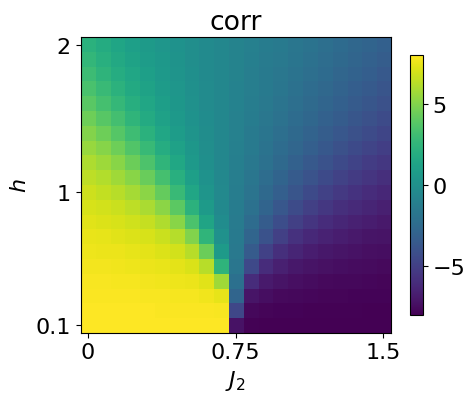

In [ ]:
plt.rcParams['font.size'] = 16
plt.figure(figsize=(5,5),dpi=100)

plt.imshow(jnp.rot90(data_exact['corr2_gs']))
plt.ylabel(r'$h$')
plt.xlabel(r'$J_2$')
plt.colorbar(shrink=0.675)
plt.title(r'corr')


y_tick_positions = [0,10,19]
y_tick_labels = ['2', '1', '0.1']
plt.yticks(y_tick_positions, y_tick_labels)

x_tick_positions = [0, 10, 20]
x_tick_labels = ['0', '0.75', '1.5']
plt.xticks(x_tick_positions, x_tick_labels)

plt.show()

We now generate the data using the exact wavefunction. To do so, we simply sample spin values from the probabilities given by the exact wavefunction using the function `sample_spin_configurations` from `qdisc.dataset`

In [ ]:
## generate the data ##
from qdisc.dataset.core import sample_spin_configurations

num_sample_per_params = 1000
data = jnp.zeros([jnp.size(all_J2), jnp.size(all_h), num_sample_per_params, N])

key = jax.random.PRNGKey(8324)

wave_fcts = data_exact['wave_fcts']

for i, J2 in enumerate(all_J2):
  for j, h in enumerate(all_h):
      #print('J2: {}, h: {}'.format(J2,h))
      key, subkey = jax.random.split(key)
      samples = sample_spin_configurations(wave_fcts[i,j], num_samples=num_sample_per_params, N=N, key=subkey)
      data = data.at[i,j].set(samples)


To check the data, we can look at the magnetization across the parameter space by just computing the average mean

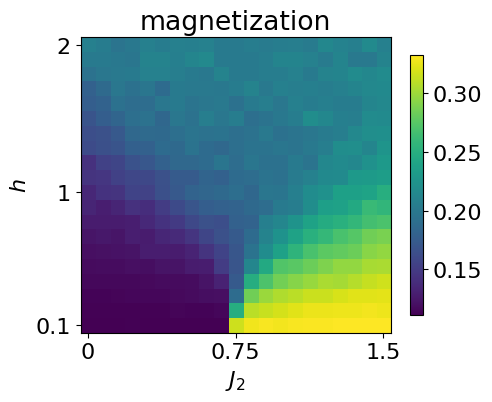

In [ ]:
plt.rcParams['font.size'] = 16
plt.figure(figsize=(5,5),dpi=100)

plt.imshow(jnp.rot90(jnp.mean(jnp.abs(jnp.mean(data*2-1, axis=-1)), axis=-1)))
plt.ylabel(r'$h$')
plt.xlabel(r'$J_2$')
plt.colorbar(shrink=0.675)
plt.title(r'magnetization')


y_tick_positions = [0,10,19]
y_tick_labels = ['2', '1', '0.1']
plt.yticks(y_tick_positions, y_tick_labels)

x_tick_positions = [0, 10, 20]
x_tick_labels = ['0', '0.75', '1.5']
plt.xticks(x_tick_positions, x_tick_labels)

plt.show()

We next cast the generated data into a **`qdisc.Dataset`** object, which provides a unified interface for handling quantum data within the qdisc pipeline.

To construct the dataset, the following information must be specified:
- the values of the tuning parameters,
- the type of quantum data,
- the dimension of the local Hilbert space,
- the values of the local states (for discrete data).


In [ ]:
from qdisc.dataset.core import Dataset

dataset = Dataset(data=data, thetas=[all_J2, all_h], data_type='discrete', local_dimension=2, local_states=jnp.array([0,1]))

## Learning a latent representation of the phase space

With the dataset in hand, we now learn a representation of the phase space. This is achieved using a **variational autoencoder ** trained to reconstruct the **conditional probabilities** of its input data, here, spin configurations.

The VAE consists of two neural networks:
- an **encoder**, which here takes a spin configuration as input and outputs a mean $\mu_i$ and variance $\sigma_i$ defining a latent distribution $N(\mu_i,\sigma_i)$, from which a latent variable $z_i$ is sampled;
- a **decoder**, which reconstructs the conditional probabilities of the spin configuration given the latent variables $\mathbf{z}$.

Both the encoder and decoder are implemented using the **Flax** library.

Several model architectures are available in **`qdisc.nn`**. Given the simplicity of the present system, we use:
- a **convolutional neural network** for the encoder, and
- a **dense masked network** for the decoder.

One of the strengths of VAEs is their ability to **adaptively learn the effective dimensionality** of the latent space. In practice, this allows us to choose a latent dimension larger than what is physically expected and let the model determine how many latent variables are actually needed.

Here, we set `latent_dim = 5` while creating the encoder.

In [ ]:
from qdisc.nn.core import EncoderCNN2D, ARNNDense

encoder = EncoderCNN2D(latent_dim=5, conv_features = 4*N, dense_features = 4*N, num_conv_layers=3)
decoder = ARNNDense(num_layers=4, features=4*N)

Then we can simply create our VAE, from **qdisc.vae**, using the encoder and the decoder:

In [ ]:
from qdisc.vae.core import VAEmodel

myvae = VAEmodel(encoder=encoder, decoder=decoder)

The main object of this section is the trainer wrapper of the VAE, which is also implemented in **qdisc.VAE**. Its primary function is to train the model and compute the learned representation.
We can simply create it using our VAE and dataset:

In [ ]:
from qdisc.vae.core import VAETrainer

myvaetrainer = VAETrainer(model=myvae, dataset=dataset)

To train the model, we use the `.train()` method, specifying:
- a random key (for reproducibility),
- the number of training epochs,
- the loss hyperparameters $\alpha$, $\beta$, and $\gamma$.  
The training objective is defined as
$$
\mathcal{L} = \frac{1}{M}\sum_{m=1}^{M} \mathbb{E}_q[\log p(x^{(m)} \mid z)] - \beta \mathrm{KL}[q(z \mid x^{(m)}) \| p(z)]
$$
where $M$ denotes the number of training samples $x^{(m)}$.

The first term promotes accurate probabilistic reconstruction of the input data.  
The second term is a regularization term that minimizes the Kullback–Leibler (KL) divergence between the latent posterior
$q(z_i) \sim \mathcal{N}(\mu_i, \sigma_i)$
and the standard normal prior $\mathcal{N}(0,1)$.

This regularization enforces the latent representation to remain close to an uninformed prior. The competition between the reconstruction and KL terms naturally leads to a sparse latent structure: only the minimum number of latent neurons required for faithful reconstruction deviate from the prior (referred to as **active neurons**), while the remaining ones collapse to the prior distribution (referred to as **passive neurons**). The hyperparameter $\beta$ controls the balance between these two contributions.

In addition, the library allows weighting the statistical correlations between latent neurons with the hyperparameter $\gamma$. This regularization can improve interpretability of the learned representation and, in some cases, simplify hyperparameter tuning. For details, we refer the reader to the original TCVAE paper (https://tinyurl.com/4r4pjkum).


Finally, for hybrid data, the reconstruction loss itself is composed of two distinct terms. The hyperparameter $\alpha$ controls the relative weight between these contributions. For more details, see the corresponding paper or the example notebook illustrating on the FKM.


In [ ]:
# !!! This takes a few seconds on a GPU, but around an hour on a CPU. 
# If you don't want to spend this time, you can just load the trained data by running the next cell. 
key = jax.random.PRNGKey(9812)
num_epochs = 30
myvaetrainer.train(num_epochs=num_epochs, batch_size=5000, beta=.5, gamma=5, key=key, printing_rate=4)

Start training...
epoch=0 step=0 loss=-164.0816877940576 recon=6.24122033277154
logvar=[ 0.02889643  0.06553731  0.08578867  0.07469489 -0.11742282]
epoch=4 step=0 loss=-166.45211124671502 recon=2.5760088226371716
logvar=[-1.36892477e-03 -4.82999374e-02 -6.22983538e-02 -5.30253240e-02
 -5.17253551e+00]
epoch=8 step=0 loss=-166.69147796032797 recon=2.1487739147339293
logvar=[ 0.00951258 -0.01400834 -0.02464279 -0.00858941 -5.84861374]
epoch=12 step=0 loss=-166.7729565138266 recon=1.9637902448406568
logvar=[-0.03862359 -0.04633447 -0.01720772 -0.0306454  -6.30670534]
epoch=16 step=0 loss=-166.87305732748734 recon=1.8128534112447012
logvar=[-0.0251713  -0.03875362 -0.02637963 -0.02864144 -6.4948804 ]
epoch=20 step=0 loss=-166.8853334271902 recon=1.773370016137969
logvar=[-0.01703035 -0.03162701 -0.02305127 -0.0382037  -6.62230354]
epoch=24 step=0 loss=-166.97256104566398 recon=1.6597759778974905
logvar=[-0.02856087 -0.04890603 -0.03495724 -0.03407848 -6.66632657]
epoch=28 step=0 loss=-166

As suggested by simple observables such as the next-nearest-neighbour correlator, the phase space of this system can be fully characterized by a **single parameter**. We therefore expect only **one active latent neuron**, with the remaining ones collapsing to the prior.

To encourage this behavior, we use relatively large weights for the **KL divergence** and the **total correlation (TC)** terms. The TC regularization typically helps sparsify the latent representation, as an active latent variable tends to be weakly correlated with noise. When only one latent neuron is active, the TC term does not affect the learned representation but still helps suppress spurious correlations among passive neurons.


To have a better idea of what happened during the training, we can look at the reconstruction loss and the variances of the latent neurons using the `.plot_training()` method:

In [ ]:
#load the trained model
with open('J1J2_data_cpVAE2_QDisc.pkl', 'rb') as f:
    all_data = pickle.load(f)

myvaetrainer.init_state(jax.random.PRNGKey(0), dataset.data[0,0])
myvaetrainer.state = myvaetrainer.state.replace(params=all_data['params'])
myvaetrainer.history_recon = all_data['history_recon']
myvaetrainer.history_logvar = all_data['history_logvar']
num_epochs = 30

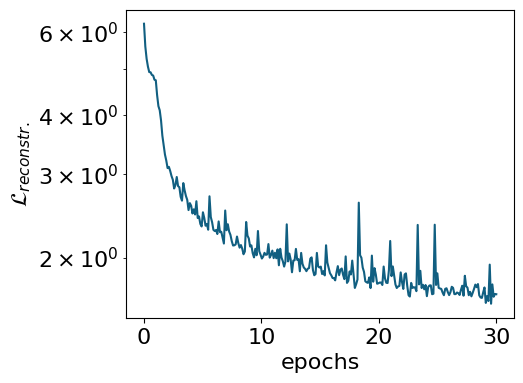

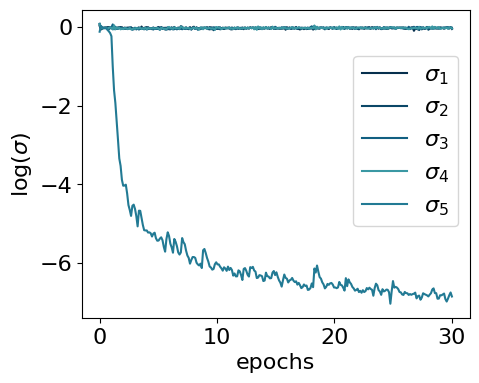

In [ ]:
myvaetrainer.plot_training(num_epochs = num_epochs)

We see that the model learns to encode information in only one active latent variable, as the variance of all the others collapses to one.

Now, it is interesting to look at the representation that the model has learned. This can be computed using the `compute_repr2d()` method and visualized using the `plot_repr2d()` method. Alternatively, both steps can be performed using the .compute_and_plot_repr2d() method, as demonstrated below:

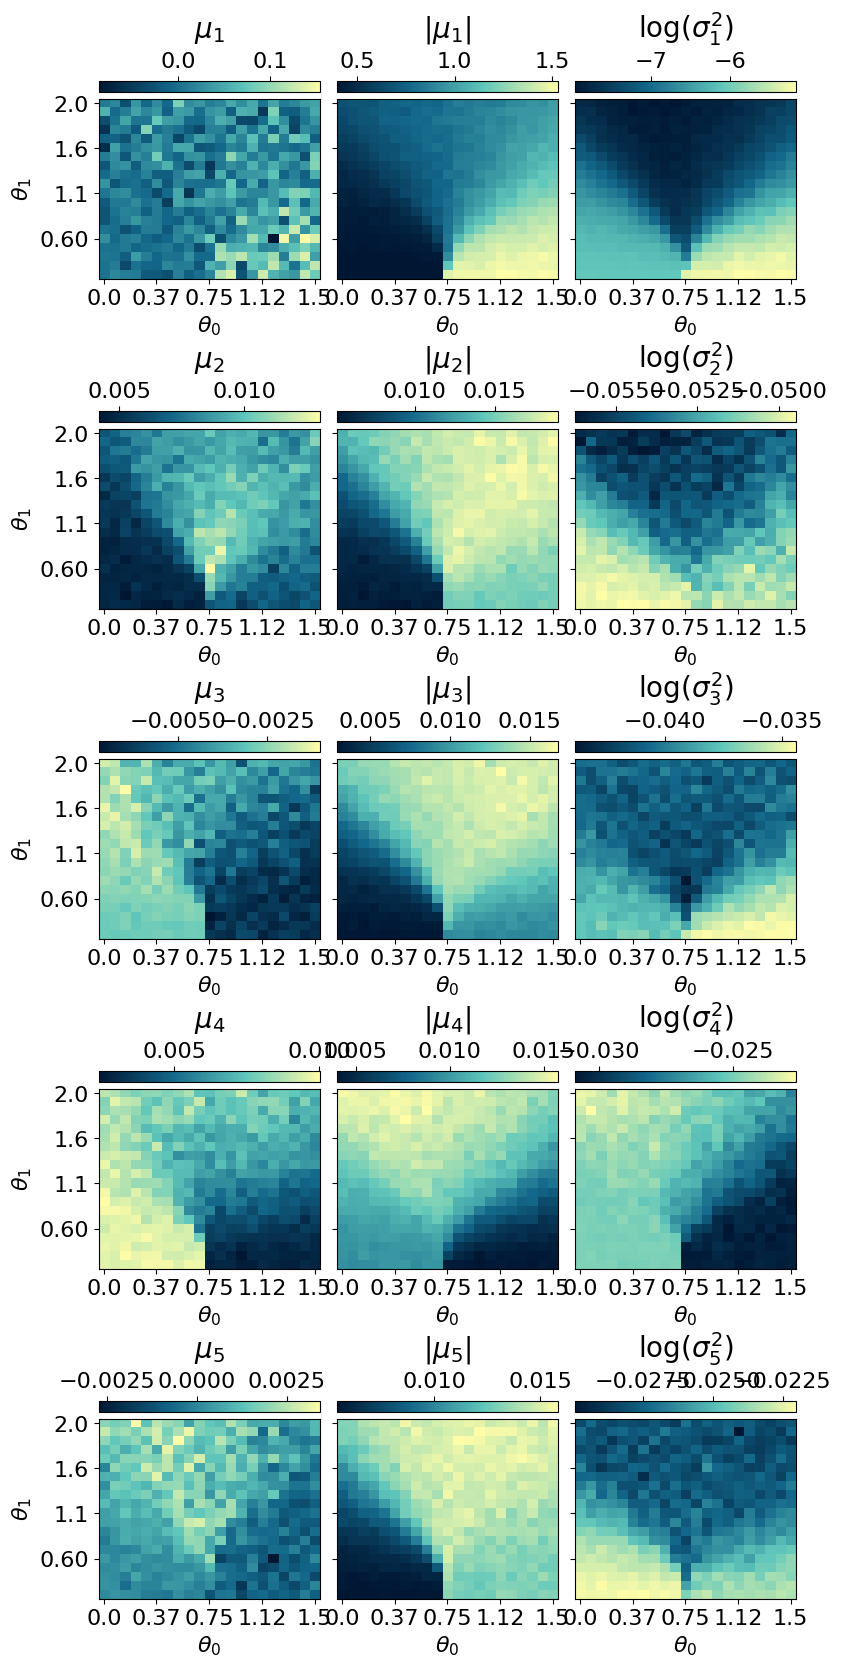

In [ ]:
#latvar = myvaetrainer.compute_repr2d(return_latvar = True) #this also update the attribute latvar of the object
#myvaetrainer.plot_repr2d()

## or one can do both by just calling
# now the latent variables are ordered with respect to the values of their logvar: from low (most active) to high (most passive)
myvaetrainer.compute_and_plot_repr2d()

During training, the VAE reduces its reconstruction loss. However, a low reconstruction loss alone does not guarantee that the model faithfully approximates the true ground state. It is therefore essential to explicitly assess the **quality of the reconstructed physical observables**.

A common approach is to generate samples from the decoder and compute statistical estimates of selected observables. In our example, this is done by sampling spin configurations from the learned conditional distribution.

Below, we use the `.reconstruct_sample()` method to generate spin configurations at each point in parameter space and then compute the **average magnetization** across the full parameter range.

In [ ]:
reconstruct_sample = jnp.zeros_like(dataset.data)
key = jax.random.PRNGKey(2687)

for i in range(dataset.data.shape[0]):
  for j in range(dataset.data.shape[1]):
    subkey, key = jax.random.split(key)
    reconstruct_sample = reconstruct_sample.at[i,j].set(myvaetrainer.reconstruct_sample(dataset.data[i,j],subkey))


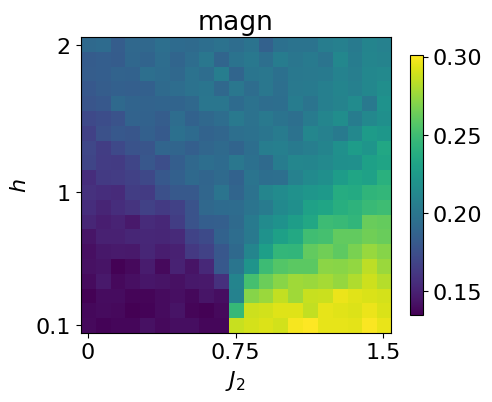

In [ ]:
plt.rcParams['font.size'] = 16
plt.figure(figsize=(5,5),dpi=100)

plt.imshow(jnp.rot90(jnp.mean(jnp.abs(jnp.mean(reconstruct_sample*2-1,axis=(-1))),axis=-1)))
plt.ylabel(r'$h$')
plt.xlabel(r'$J_2$')
plt.colorbar(shrink=0.675)
plt.title(r'magn')


y_tick_positions = [0,10,19]
y_tick_labels = ['2', '1', '0.1']
plt.yticks(y_tick_positions, y_tick_labels)

x_tick_positions = [0, 10, 20]
x_tick_labels = ['0', '0.75', '1.5']
plt.xticks(x_tick_positions, x_tick_labels)

plt.show()

This can be compared with the magnetization computed directly from the dataset.

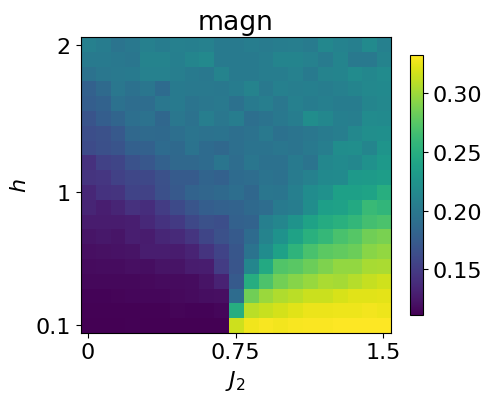

In [ ]:
plt.rcParams['font.size'] = 16
plt.figure(figsize=(5,5),dpi=100)

plt.imshow(jnp.rot90(jnp.mean(jnp.abs(jnp.mean(dataset.data*2-1,axis=(-1))),axis=-1)))
plt.ylabel(r'$h$')
plt.xlabel(r'$J_2$')
plt.colorbar(shrink=0.675)
plt.title(r'magn')


y_tick_positions = [0,10,19]
y_tick_labels = ['2', '1', '0.1']
plt.yticks(y_tick_positions, y_tick_labels)

x_tick_positions = [0, 10, 20]
x_tick_labels = ['0', '0.75', '1.5']
plt.xticks(x_tick_positions, x_tick_labels)

plt.show()
#quick comparaison without setting the same cbar
#given the patterns, should be ~1/9 for neel and ~1/3 for striped
#the apparent magnetization in the polarized phase is due to the fact that we make the average of the absolute magn. (all zero due to Z2 degene otherwise)

To save the results, the method `.get_data()` can be used. It returns a dictionary containing the training history, the optimized parameters of the VAE, the learned representation, ...

In [ ]:
all_data = myvaetrainer.get_data()
all_data.keys()

dict_keys(['params', 'history_loss', 'history_recon', 'history_logvar', 'latvar'])

Then I typically save using `pickle` as shown bellow

In [ ]:
## also add the data and the exact corr ##

all_data['corr_exact'] = data_exact['corr_gs']
all_data['corr2_exact'] = data_exact['corr2_gs']
all_data['data'] = dataset.data

In [ ]:
with open('J1J2_data_cpVAE2_QDisc.pkl', 'wb') as f:
    pickle.dump(all_data, f)

The loading is simply done using

In [ ]:
with open('J1J2_data_cpVAE2_QDisc.pkl', 'rb') as f:
    all_data = pickle.load(f)

## Clustering the latent representation

In this toy example, the different phases are easily visible in the learned latent representation. For more complex phase diagrams or higher-dimensional representations, however, identifying phase boundaries by eye can become challenging. To address this, **qdisc provides clustering tools** that operate directly on the learned latent space to automatically identify distinct phases.

The clustering algorithm currently implemented is a **Gaussian Mixture Model (GMM)**. The GMM is applied to a feature vector $X$ constructed as follows:
- the first component consists of the average values of the **active latent variable** across the parameter space;
- the (normalized) tuning parameters $\theta_i$ are appended to this vector.

Including the tuning parameters helps the GMM identify clusters with smoother and more well-defined boundaries. The relative contribution of the tuning parameters is controlled by a weighting parameter $\alpha$.

To use `qdisc.clustering.GaussianMixture()`, one must specify:
- the number of clusters (phases),
- the maximum number of iterations.

An optional initialization using $k$-means can be enabled by setting `init_params="kmeans"`.


GMM with n_components: 2


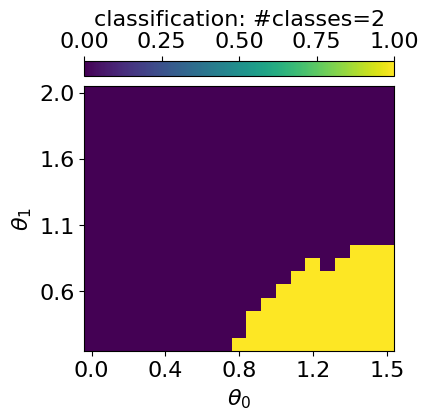

GMM with n_components: 3


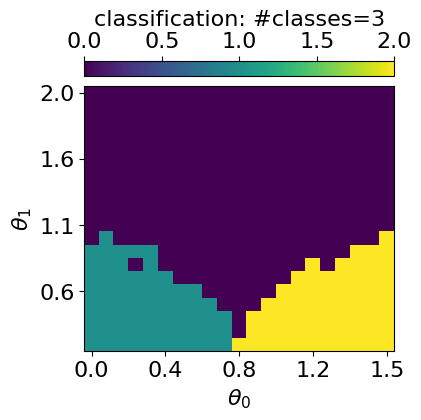

GMM with n_components: 4


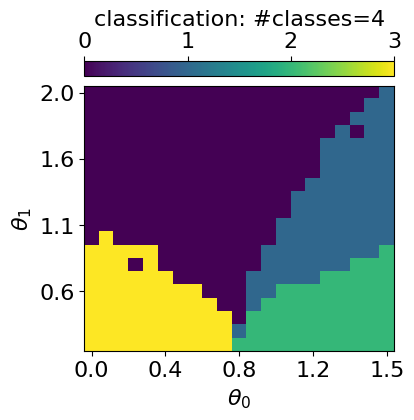

GMM with n_components: 5


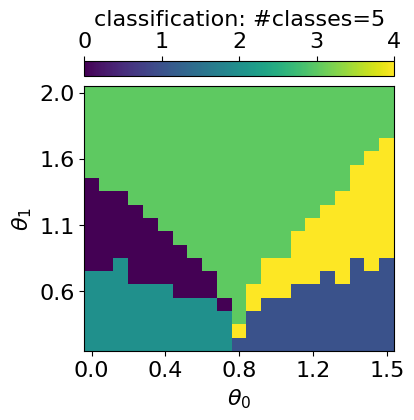

In [ ]:
from qdisc.clustering.core import GaussianMixture

## get the latent representation
#latvar = myvaetrainer.latvar
latvar = all_data['latvar']
data = all_data['data']
mu0abs = latvar['mu0_abs']
theta_pair = (1,0)#latvar['theta_pair']

#get the experimental parameters thetas to weight on the parameter space distance by alpha and have a smooter clustering
alpha = 0.001
theta1 = dataset.thetas[theta_pair[0]]
theta2 = dataset.thetas[theta_pair[1]]
theta1_norm = (theta1 - jnp.min(theta1)) / (jnp.max(theta1) - jnp.min(theta1))
theta2_norm = (theta2 - jnp.min(theta2)) / (jnp.max(theta2) - jnp.min(theta2))

#vector to perform the GMM one
X = jnp.array([mu0abs.reshape(-1), alpha*jnp.tile(theta1_norm[:,None], reps=(jnp.size(theta2_norm),)).reshape(-1), alpha*jnp.tile(theta2_norm[None, :], reps=(jnp.size(theta1_norm),)).reshape(-1)]).transpose()


for n_components in [2,3,4,5]:

    print('GMM with n_components: {}'.format(n_components))

    clusterer = GaussianMixture(
                                n_components=n_components,
                                max_iter=500,
                                init_params="kmeans"
                            )

    clusterer.fit(X, key=jax.random.PRNGKey(4362))



    classes = clusterer.predict(X).reshape((jnp.size(theta1),jnp.size(theta2)))

    final_classes = jnp.zeros((jnp.size(theta1),jnp.size(theta2)))
    for i in range(jnp.size(theta1)):
      for j in range(jnp.size(theta2)):
        v, c = jnp.unique_counts(classes[i,j])
        final_classes = final_classes.at[i,j].set(v[jnp.argmax(c)])



    fig_shape = (len(theta1)/5, len(theta2)/5)

    plt.rcParams['font.size'] = 16
    plt.figure(figsize=fig_shape,dpi=100)

    plt.imshow(jnp.flipud(final_classes), aspect='auto')
    cbar = plt.colorbar(orientation="horizontal", pad=0.03, location="top")
    cbar.set_label(r'classification: #classes={}'.format(n_components))


    plt.ylabel(r'$\theta_{}$'.format(theta_pair[0]))
    plt.xlabel(r'$\theta_{}$'.format(theta_pair[1]))
    plt.yticks([i for i in range(0,len(theta1),len(theta1)//4)], [str(theta1[len(theta1)-i])[:3] for i in range(0,len(theta1),len(theta1)//4)])
    plt.xticks([i for i in range(0,len(theta2)+1,len(theta2)//4)], [str(theta2[i])[:3] for i in range(1,len(theta2)+1,len(theta2)//4)])

    plt.show()

To find the optimal number of classes, qdisc.clustering provide the `select_n_components()` function which can be used as shown below

In [ ]:
from qdisc.clustering.core import select_n_components
## Can also compute some metrics to evaluate the optimal number of class

ks = range(2, 7)  # ranges of n_components tested
results = select_n_components(X, ks, n_init=5, max_iter=500, random_seed=2546)

# collect bic/aic/loglikelihood
bics = jnp.array([results[k]['metrics']['bic'] for k in ks])
aics = jnp.array([results[k]['metrics']['aic'] for k in ks])
avg_lls = jnp.array([results[k]['metrics']['avg_log_likelihood'] for k in ks])

# K that minimizes BIC/AIC
best_k_bic = ks[jnp.argmin(bics)]
best_k_aic = ks[jnp.argmin(aics)]
print("Best K (BIC):", best_k_bic, "Best K (AIC):", best_k_aic)

#3 is indeed the best (neel, pola, striped), the fourth one is a phase boundary (can also be interesting)

Trying K=2
Trying K=3
Trying K=4
Trying K=5
Trying K=6
Best K (BIC): 3 Best K (AIC): 5


results GMM n_components: 2
BIC: -9700.291536668057
AIC: -9777.056376182329
avg_log_likelihood: 11.684590924026583
results GMM n_components: 3
BIC: -9810.477975436434
AIC: -9927.645362063478
avg_log_likelihood: 11.88767305007557
results GMM n_components: 4
BIC: -9763.699312877627
AIC: -9921.269246617445
avg_log_likelihood: 11.903891960258864
results GMM n_components: 5
BIC: -9738.231419973254
AIC: -9936.203900825847
avg_log_likelihood: 11.945480834316486
results GMM n_components: 6
BIC: -9683.22510978266
AIC: -9921.600137748026
avg_log_likelihood: 11.951904925890508


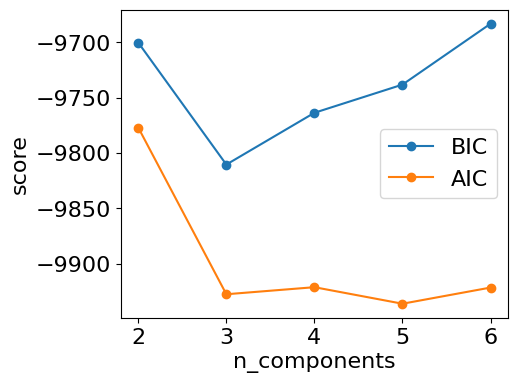

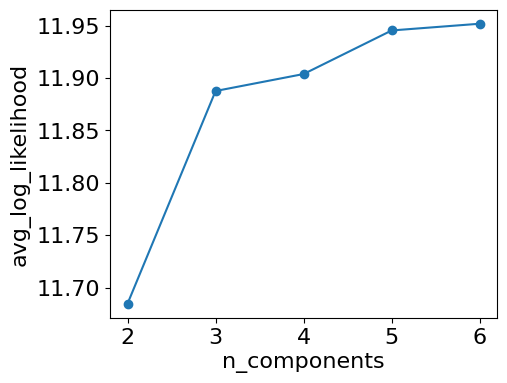

In [ ]:
## plot of each metrics

from matplotlib import pyplot as plt


for i, k in enumerate(ks):
  print('results GMM n_components: {}'.format(k))
  print('BIC: {}'.format(bics[i]))
  print('AIC: {}'.format(aics[i]))
  print('avg_log_likelihood: {}'.format(avg_lls[i]))



plt.rcParams['font.size'] = 16
plt.figure(figsize=(5,4),dpi=100)

plt.plot(ks, bics, 'o-', label='BIC')
plt.plot(ks, aics, 'o-', label='AIC')
#plt.plot(ks, avg_lls, 'o-', label='avg_log_likelihood')

plt.xlabel('n_components')
plt.ylabel('score')
plt.legend()


plt.rcParams['font.size'] = 16
plt.figure(figsize=(5,4),dpi=100)

plt.plot(ks, avg_lls, 'o-', label='avg_log_likelihood')
plt.xlabel('n_components')
plt.ylabel('avg_log_likelihood')

plt.show()
#3 also leads to a big increase og log_likelihood

## Symbolic regression

For the **symbolic regression (SR)** tools implemented in qdisc, please refer to the second tutorial notebook. 